# Stage 16 — Multi-scale Ablation Training

Trains ProtoSegNet with a restricted set of prototype levels to evaluate whether multi-scale supervision is necessary.

**Change `PROTO_LEVELS` in Cell 1 to switch between ablation models:**
- `[4]` → M1 (L4-only, deepest semantic level only)
- `[3, 4]` → M2 (L3+L4)
- `[1, 2, 3, 4]` → M4 (full, already trained as v1)

Same hyperparameters as v1 `_l2`: λ_div=0.001, λ_push=0.5, λ_pull=0.25, 3-phase schedule.

## 0. Config

In [1]:
import sys, os
_root = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
os.chdir(_root)
sys.path.insert(0, _root)
os.environ.setdefault('PYTORCH_MPS_HIGH_WATERMARK_RATIO', '0.0')
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

# ── Ablation config ───────────────────────────────────────────────────────────
PROTO_LEVELS = [3, 4]        # M2: L3+L4
MODALITY     = 'ct'
SUFFIX       = '_l3l4'       # M2: L3+L4

# ── Hyperparameters (same as v1 _l2) ─────────────────────────────────────────
LAMBDA_DIV   = 0.001
LAMBDA_PUSH  = 0.5
LAMBDA_PULL  = 0.25
BATCH_SIZE   = 16
LR           = 3e-4
WEIGHT_DECAY = 1e-5
PHASE_A_END  = 20
PHASE_B_END  = 80
PHASE_C_END  = 100
VAL_EVERY    = 5
PATIENCE     = 15
PROJ_INTERVAL = 10

DATA_DIR  = 'data/pack/processed_data'
CKPT_DIR  = 'checkpoints'
LOG_DIR   = 'results/v4'

import pathlib
pathlib.Path(LOG_DIR).mkdir(parents=True, exist_ok=True)

CKPT_PATH = f'{CKPT_DIR}/proto_seg_{MODALITY}{SUFFIX}.pth'
PROJ_PATH = f'{CKPT_DIR}/projected_prototypes_{MODALITY}{SUFFIX}.pt'
LOG_PATH  = f'{LOG_DIR}/train_curve_proto_{MODALITY}{SUFFIX}.csv'

print(f'proto_levels : {PROTO_LEVELS}')
print(f'checkpoint   : {CKPT_PATH}')
print(f'log          : {LOG_PATH}')

proto_levels : [3, 4]
checkpoint   : checkpoints/proto_seg_ct_l3l4.pth
log          : results/v4/train_curve_proto_ct_l3l4.csv


## 1. Imports & Setup

In [2]:
import csv, time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from src.data.mmwhs_dataset import (
    MMWHSSliceDataset, make_dataloaders, LABEL_NAMES, NUM_CLASSES
)
from src.models.proto_seg_net import ProtoSegNet
from src.models.prototype_layer import PrototypeProjection
from src.losses.segmentation import SegmentationLoss, compute_class_weights
from src.losses.diversity_loss import ProtoSegLoss
from src.metrics.dice import dice_per_class, mean_foreground_dice

DEVICE = (
    torch.device('mps')  if torch.backends.mps.is_available()  else
    torch.device('cuda') if torch.cuda.is_available()          else
    torch.device('cpu')
)
print(f'Device: {DEVICE}')

Device: mps


## 2. Data & Model

In [3]:
loaders = make_dataloaders(DATA_DIR, MODALITY, batch_size=BATCH_SIZE)
print(f"Train: {len(loaders['train'].dataset)}  Val: {len(loaders['val'].dataset)}  "
      f"Test: {len(loaders['test'].dataset)}")

weights_path = f'data/class_weights_{MODALITY}.pt'
if pathlib.Path(weights_path).exists():
    class_weights = torch.load(weights_path, weights_only=True)
else:
    class_weights = compute_class_weights(DATA_DIR, MODALITY)
    torch.save(class_weights, weights_path)

model = ProtoSegNet(n_classes=NUM_CLASSES, proto_levels=PROTO_LEVELS).to(DEVICE)
print(f'proto_levels : {model.proto_levels}')
print(f'proto_layers : {list(model.proto_layers.keys())}')
print(f'Total params : {model.count_parameters()["total"]:,}')

seg_loss  = SegmentationLoss(class_weights=class_weights.to(DEVICE), n_classes=NUM_CLASSES)
criterion = ProtoSegLoss(
    seg_loss=seg_loss,
    lambda_div=LAMBDA_DIV,
    lambda_push=LAMBDA_PUSH,
    lambda_pull=LAMBDA_PULL,
)

Train: 3389  Val: 382  Test: 484
proto_levels : [3, 4]
proto_layers : ['3', '4']
Total params : 2,553,704


## 3. Helpers

In [4]:
@torch.no_grad()
def validate(model, loader):
    model.eval()
    logits_list, labels_list = [], []
    for batch in loader:
        logits, _ = model(batch['image'].to(DEVICE))
        logits_list.append(logits.cpu())
        labels_list.append(batch['label'])
    model.train()
    return dice_per_class(torch.cat(logits_list), torch.cat(labels_list))


def run_projection(model, save_path):
    print('  [Projection] Building feature bank on CPU…', flush=True)
    t0 = time.time()
    proj_ds = MMWHSSliceDataset(DATA_DIR, MODALITY, 'train', augment=False, preload=True)
    proj_loader = torch.utils.data.DataLoader(proj_ds, batch_size=32, shuffle=False)
    wrapped = [(b['image'], b['label']) for b in proj_loader]
    projector = PrototypeProjection(
        encoder=model.encoder,
        proto_layers=model.proto_layers_dict(),
        device='cpu',
    )
    projector.project(wrapped, save_path=save_path)
    model.to(DEVICE)
    ckpt = torch.load(save_path, weights_only=True)
    for level, proto_data in ckpt['proto_state'].items():
        model.proto_layers[str(level)].prototypes.data.copy_(proto_data)
    print(f'  [Projection] Done in {time.time()-t0:.1f}s', flush=True)


def set_phase(model, epoch, optimizer):
    if epoch <= PHASE_A_END:
        model.unfreeze_all(); model.freeze_prototypes(); phase = 'A'
    elif epoch <= PHASE_B_END:
        model.unfreeze_all(); phase = 'B'
    else:
        model.freeze_encoder_and_prototypes(); phase = 'C'
    optimizer.param_groups[0]['params'] = [p for p in model.parameters() if p.requires_grad]
    return phase


def save_checkpoint(epoch, model, optimizer, best_val_dice):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'best_val_dice': best_val_dice,
        'proto_levels': model.proto_levels,
        'class_weights': class_weights,
        'lambda_div': LAMBDA_DIV,
        'lambda_push': LAMBDA_PUSH,
        'lambda_pull': LAMBDA_PULL,
        'single_scale': model.single_scale,
        'no_soft_mask': model.no_soft_mask,
        'hard_mask': model.hard_mask,
        'mask_quantile': model.mask_quantile,
        'hard_mask_active': model.hard_mask_active,
    }, CKPT_PATH)

## 4. Training Loop
3-phase schedule identical to v1. Expected time: ~40 min (CT, MPS).

In [5]:
model.freeze_prototypes()
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR, weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE_C_END)

fieldnames = (
    ['epoch', 'phase', 'train_loss', 'train_dice_loss', 'train_ce_loss',
     'train_div_loss', 'train_push_loss', 'train_pull_loss',
     'val_mean_fg_dice', 'lr', 'epoch_time_s']
    + [f'val_dice_{LABEL_NAMES[c]}' for c in range(1, NUM_CLASSES)]
)
csv_file = open(LOG_PATH, 'w', newline='')
writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
writer.writeheader()

best_val_dice, best_epoch, no_improve = 0.0, 0, 0
current_phase = 'A'
history = []

print(f'Training ProtoSegNet  proto_levels={PROTO_LEVELS}  suffix={SUFFIX}')
print(f'λ_div={LAMBDA_DIV}  λ_push={LAMBDA_PUSH}  λ_pull={LAMBDA_PULL}')
print(f'Phase A: epochs 1–{PHASE_A_END}  (prototypes frozen)\n')

for epoch in range(1, PHASE_C_END + 1):

    new_phase = set_phase(model, epoch, optimizer)
    if new_phase != current_phase:
        current_phase = new_phase
        if current_phase == 'B':
            print(f'\n→ Phase B: all params  (epochs {PHASE_A_END+1}–{PHASE_B_END})')
            run_projection(model, PROJ_PATH)
            best_val_dice, best_epoch, no_improve = 0.0, 0, 0
        elif current_phase == 'C':
            print(f'\n→ Phase C: decoder only  (epochs {PHASE_B_END+1}–{PHASE_C_END})')

    if (current_phase == 'B'
            and epoch > PHASE_A_END + 1
            and (epoch - PHASE_A_END) % PROJ_INTERVAL == 0):
        run_projection(model, PROJ_PATH)

    # ── Train epoch ───────────────────────────────────────────────────────
    t0 = time.time()
    model.train()
    totals = dict(loss=0, dice=0, ce=0, div=0, push=0, pull=0)
    n_batches = 0

    for batch in loaders['train']:
        imgs = batch['image'].to(DEVICE)
        lbls = batch['label'].to(DEVICE)
        optimizer.zero_grad()
        logits, hm = model(imgs)

        if current_phase == 'A':
            out = seg_loss(logits, lbls)
            out['div_loss'] = out['push_loss'] = out['pull_loss'] = torch.zeros(1, device=DEVICE)
        else:
            out = criterion(logits, lbls, hm)

        out['loss'].backward()
        nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], 1.0)
        optimizer.step()

        totals['loss'] += out['loss'].item()
        totals['dice'] += out['dice_loss'].item()
        totals['ce']   += out['ce_loss'].item()
        totals['div']  += out['div_loss'].item()
        totals['push'] += out['push_loss'].item()
        totals['pull'] += out['pull_loss'].item()
        n_batches += 1

    scheduler.step()
    ep_time = time.time() - t0
    avg = {k: v / n_batches for k, v in totals.items()}
    lr_now = scheduler.get_last_lr()[0]

    row = {
        'epoch': epoch, 'phase': current_phase,
        'train_loss': round(avg['loss'], 5),
        'train_dice_loss': round(avg['dice'], 5),
        'train_ce_loss':   round(avg['ce'],   5),
        'train_div_loss':  round(avg['div'],  5),
        'train_push_loss': round(avg['push'], 6),
        'train_pull_loss': round(avg['pull'], 6),
        'lr': round(lr_now, 7),
        'epoch_time_s': round(ep_time, 1),
    }

    # ── Validation ────────────────────────────────────────────────────────
    if epoch % VAL_EVERY == 0 or epoch == 1:
        val_dice = validate(model, loaders['val'])
        val_mean = mean_foreground_dice(val_dice)
        row['val_mean_fg_dice'] = round(val_mean, 5)
        for c in range(1, NUM_CLASSES):
            v = val_dice.get(LABEL_NAMES[c], float('nan'))
            row[f'val_dice_{LABEL_NAMES[c]}'] = round(v, 4) if v == v else 'nan'

        if val_mean > best_val_dice:
            best_val_dice, best_epoch, no_improve = val_mean, epoch, 0
            save_checkpoint(epoch, model, optimizer, best_val_dice)
            flag = ' ← best'
        else:
            no_improve += 1; flag = ''

        history.append({'epoch': epoch, 'val': val_mean, 'loss': avg['loss']})
        print(f'  [{current_phase}] Ep {epoch:3d}/{PHASE_C_END} | '
              f'loss={avg["loss"]:.4f} (D={avg["dice"]:.4f} CE={avg["ce"]:.4f} '
              f'div={avg["div"]:.4f} push={avg["push"]:.4f} pull={avg["pull"]:.4f}) | '
              f'val={val_mean:.4f}{flag} | lr={lr_now:.2e} | {ep_time:.1f}s', flush=True)
    else:
        row['val_mean_fg_dice'] = ''
        for c in range(1, NUM_CLASSES): row[f'val_dice_{LABEL_NAMES[c]}'] = ''
        if epoch % 10 == 0:
            print(f'  [{current_phase}] Ep {epoch:3d}/{PHASE_C_END} | '
                  f'loss={avg["loss"]:.4f} | lr={lr_now:.2e} | {ep_time:.1f}s', flush=True)

    writer.writerow(row)
    csv_file.flush()

    if current_phase != 'A' and no_improve >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} checks)')
        break

csv_file.close()
print(f'\nBest val Dice: {best_val_dice:.4f} at epoch {best_epoch}')
print(f'Checkpoint   : {CKPT_PATH}')
print(f'Log          : {LOG_PATH}')

Training ProtoSegNet  proto_levels=[3, 4]  suffix=_l3l4
λ_div=0.001  λ_push=0.5  λ_pull=0.25
Phase A: epochs 1–20  (prototypes frozen)



  [A] Ep   1/100 | loss=1.3294 (D=0.9455 CE=1.7133 div=0.0000 push=0.0000 pull=0.0000) | val=0.2277 ← best | lr=3.00e-04 | 27.8s


  [A] Ep   5/100 | loss=0.3002 (D=0.3368 CE=0.2636 div=0.0000 push=0.0000 pull=0.0000) | val=0.6572 ← best | lr=2.98e-04 | 28.4s


  [A] Ep  10/100 | loss=0.1245 (D=0.1331 CE=0.1158 div=0.0000 push=0.0000 pull=0.0000) | val=0.7537 ← best | lr=2.93e-04 | 27.5s


  [A] Ep  15/100 | loss=0.0893 (D=0.0980 CE=0.0807 div=0.0000 push=0.0000 pull=0.0000) | val=0.8091 ← best | lr=2.84e-04 | 27.5s


...

  [C] Ep  85/100 | loss=-0.2186 (D=0.0502 CE=0.0363 div=64.5539 push=-0.9696 pull=0.6337) | val=0.8341 | lr=1.63e-05 | 20.9s


  [C] Ep  90/100 | loss=-0.2190 (D=0.0497 CE=0.0360 div=64.5490 push=-0.9696 pull=0.6337) | val=0.8361 | lr=7.34e-06 | 21.0s


  [C] Ep  95/100 | loss=-0.2190 (D=0.0501 CE=0.0358 div=64.5070 push=-0.9698 pull=0.6340) | val=0.8339 | lr=1.85e-06 | 21.2s


  [C] Ep 100/100 | loss=-0.2193 (D=0.0495 CE=0.0356 div=64.5675 push=-0.9697 pull=0.6335) | val=0.8339 | lr=0.00e+00 | 20.9s



Best val Dice: 0.8380 at epoch 80
Checkpoint   : checkpoints/proto_seg_ct_l3l4.pth
Log          : results/v4/train_curve_proto_ct_l3l4.csv


## 5. Training Curves

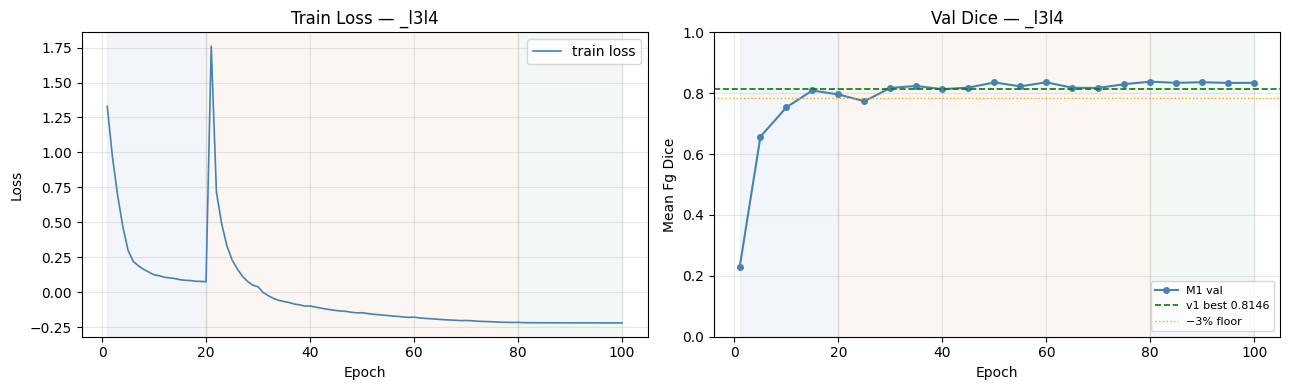

Best val Dice: 0.8380 (v1: 0.8146)


In [6]:
import pandas as pd
log = pd.read_csv(LOG_PATH)
val = log.dropna(subset=['val_mean_fg_dice'])

PHASE_COLORS = {'A': '#4C72B0', 'B': '#DD8452', 'C': '#55A868'}
V1_BEST = 0.8146   # v1 best val Dice for reference

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
max_ep = log['epoch'].max()
for ax in (ax1, ax2):
    ax.axvspan(1,            PHASE_A_END, alpha=0.07, color=PHASE_COLORS['A'])
    ax.axvspan(PHASE_A_END,  PHASE_B_END, alpha=0.07, color=PHASE_COLORS['B'])
    ax.axvspan(PHASE_B_END,  max_ep,      alpha=0.07, color=PHASE_COLORS['C'])

ax1.plot(log['epoch'], log['train_loss'], lw=1.2, color='steelblue', label='train loss')
ax1.set(title=f'Train Loss — {SUFFIX}', xlabel='Epoch', ylabel='Loss')
ax1.grid(alpha=0.3); ax1.legend()

ax2.plot(val['epoch'], val['val_mean_fg_dice'], 'o-', ms=4, lw=1.5, color='steelblue', label='M1 val')
ax2.axhline(V1_BEST,        color='green',  ls='--', lw=1.2, label=f'v1 best {V1_BEST:.4f}')
ax2.axhline(V1_BEST - 0.03, color='orange', ls=':',  lw=1,   label=f'−3% floor')
ax2.set(title=f'Val Dice — {SUFFIX}', xlabel='Epoch', ylabel='Mean Fg Dice', ylim=(0, 1.0))
ax2.grid(alpha=0.3); ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'results/v4/train_curve{SUFFIX}.png', dpi=150)
plt.show()
print(f'Best val Dice: {val["val_mean_fg_dice"].max():.4f} (v1: {V1_BEST:.4f})')

## 6. Quick 3D Dice Eval

In [7]:
from src.data.mmwhs_dataset import MMWHSPatientDataset

# Load best checkpoint
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
eval_model = ProtoSegNet(n_classes=NUM_CLASSES, proto_levels=ckpt['proto_levels']).to(DEVICE)
eval_model.load_state_dict(ckpt['model_state_dict'])
eval_model.eval()
print(f'Loaded checkpoint: epoch {ckpt["epoch"]}, best val {ckpt["best_val_dice"]:.4f}')

@torch.no_grad()
def eval_3d(model, modality):
    ds = MMWHSPatientDataset(DATA_DIR, modality, 'test')
    results = {}
    for i in range(len(ds)):
        s = ds[i]
        imgs = s['image'].to(DEVICE)     # (S, 1, H, W)
        logits_all = []
        for si in range(imgs.shape[0]):
            logits, _ = model(imgs[si:si+1])
            logits_all.append(logits.cpu())
        results[s['patient']] = dice_per_class(torch.cat(logits_all), s['label'])
    return results

results = eval_3d(eval_model, MODALITY)

V1_3D = 0.843   # v1 mean fg 3D Dice
FG_NAMES = [LABEL_NAMES[c] for c in range(1, NUM_CLASSES)]

print(f'\n3D Dice — proto_levels={PROTO_LEVELS}  suffix={SUFFIX}')
print(f'{"Patient":<12} {"MeanFg":>7}  ' + '  '.join(f'{n[:4]:>5}' for n in FG_NAMES))
print('─' * 75)
all_means = []
for pid, dice in sorted(results.items()):
    mfg = mean_foreground_dice(dice)
    all_means.append(mfg)
    vals = '  '.join(f'{dice.get(n, float("nan")):>5.3f}' for n in FG_NAMES)
    print(f'{pid:<12} {mfg:>7.4f}  {vals}')
overall = np.mean(all_means)
print('─' * 75)
print(f'{"Mean":<12} {overall:>7.4f}')
print(f'\nΔ vs v1 ({V1_3D:.3f}): {overall - V1_3D:+.4f}')
status = '✅ within 3%' if overall >= V1_3D - 0.03 else '⚠️ below floor'
print(f'Status: {status}')

Loaded checkpoint: epoch 80, best val 0.8380



3D Dice — proto_levels=[3, 4]  suffix=_l3l4
Patient       MeanFg     LV     RV     LA     RA   Myoc   Aort     PA
───────────────────────────────────────────────────────────────────────────
ct_1019       0.8123  0.849  0.901  0.718  0.897  0.712  0.868  0.741
ct_1020       0.9321  0.889  0.969  0.938  0.897  0.917  0.974  0.940
───────────────────────────────────────────────────────────────────────────
Mean          0.8722

Δ vs v1 (0.843): +0.0292
Status: ✅ within 3%
